In [12]:
SAMPLE_FOLDER = "00434"

Found 4 baseline and 4 head images.
Showing 4 paired image(s).
Prompt: a photo of a frisbee above a truck


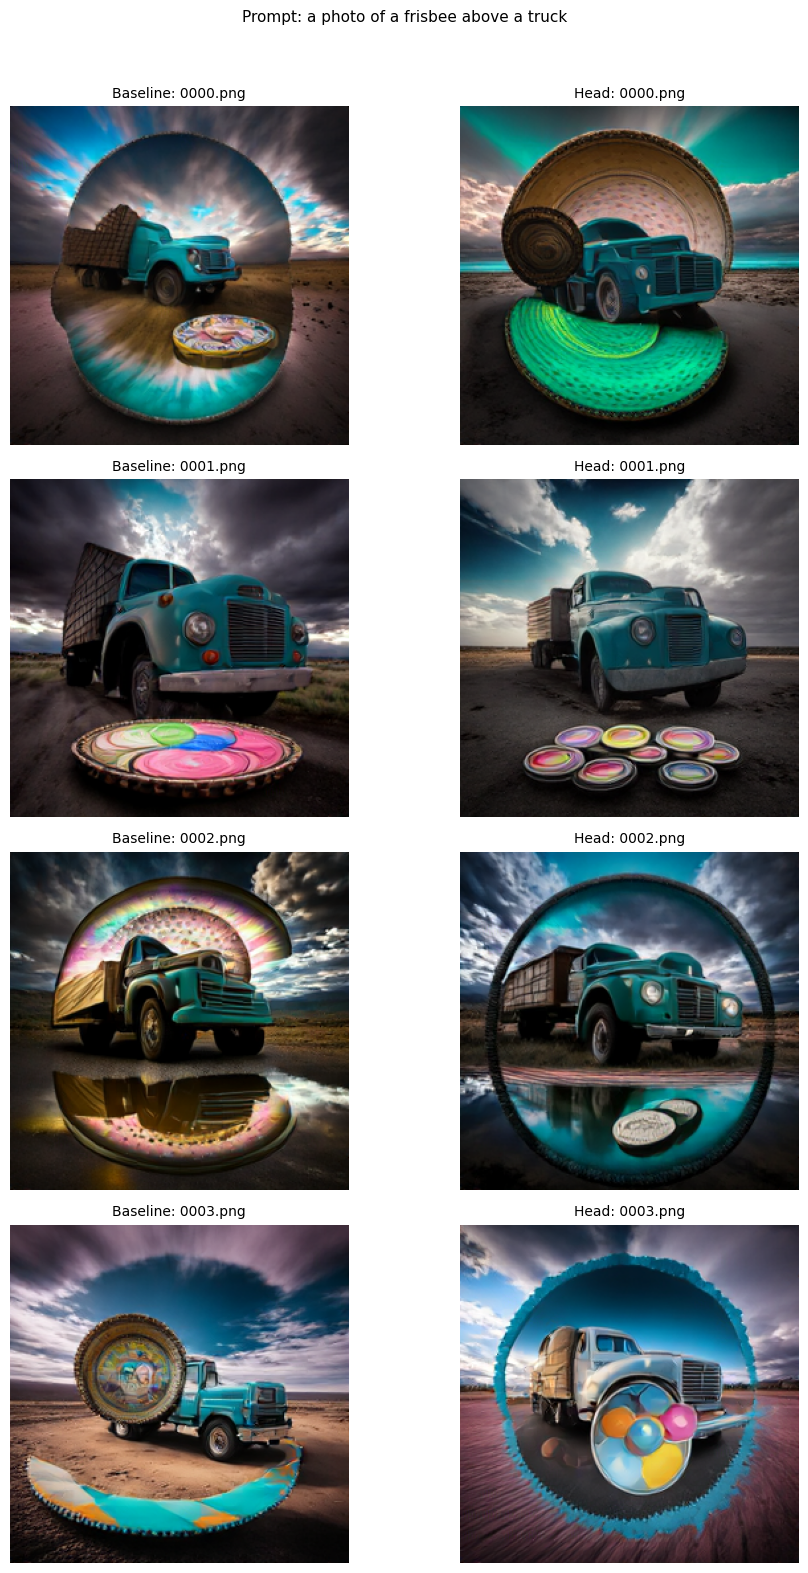

In [13]:
from pathlib import Path
import json
from PIL import Image

import matplotlib.pyplot as plt



baseline_dir = Path(f"outputs/geneval_eval/baseline_images/{SAMPLE_FOLDER}")
head_dir = Path(f"outputs/geneval_eval/head_images/{SAMPLE_FOLDER}")

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tiff"}


def load_prompt(run_dir: Path) -> str:
    metadata_path = run_dir / "metadata.jsonl"
    if not metadata_path.exists():
        return "Prompt: <missing metadata.jsonl>"

    try:
        first_line = metadata_path.read_text(encoding="utf-8").splitlines()[0]
        prompt = json.loads(first_line).get("prompt", "<prompt not found>")
        return f"Prompt: {prompt}"
    except Exception as e:
        return f"Prompt: <failed to parse metadata: {e}>"


prompt = load_prompt(baseline_dir)

baseline_images = sorted(
    p for p in (baseline_dir / "samples").iterdir() if p.is_file() and p.suffix.lower() in valid_exts
) if (baseline_dir / "samples").exists() else []

head_images = sorted(
    p for p in (head_dir / "samples").iterdir() if p.is_file() and p.suffix.lower() in valid_exts
) if (head_dir / "samples").exists() else []

pair_count = min(len(baseline_images), len(head_images), 4)
print(f"Found {len(baseline_images)} baseline and {len(head_images)} head images.")
print(f"Showing {pair_count} paired image(s).")
print(prompt)

if pair_count == 0:
    print("No paired images found.")
else:
    fig, axes = plt.subplots(pair_count, 2, figsize=(10, 4 * pair_count))
    if pair_count == 1:
        axes = [axes]

    for row in range(pair_count):
        baseline_img = Image.open(baseline_images[row])
        head_img = Image.open(head_images[row])

        left_ax, right_ax = axes[row]
        left_ax.imshow(baseline_img)
        left_ax.set_title(f"Baseline: {baseline_images[row].name}", fontsize=10)
        left_ax.axis("off")

        right_ax.imshow(head_img)
        right_ax.set_title(f"Head: {head_images[row].name}", fontsize=10)
        right_ax.axis("off")

    fig.suptitle(f"{prompt}", fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()